### Simulación con **tratamiento quimioterapéutico continuo** ($c$ + $\beta$ acoplados)

Para analizar la dinámica tumoral bajo tratamiento quimioterapéutico continuo se considera ahora la presencia de una administración externa de fármaco a lo largo del tiempo.

En este caso se introduce una tasa constante de administración,

$$
u(t)=u_0,
\qquad
u_0>0,
$$

de modo que la concentración del fármaco satisface

$$
\frac{\partial \beta}{\partial t}
-
\mu\Delta\beta
=
-\delta\beta
+
u_0.
$$

Bajo estas hipótesis, el sistema completo queda dado por

$$
\left\{
\begin{aligned}
\frac{\partial c}{\partial t}
-
\nabla \cdot \left(D(x)\nabla c\right)
&=
a\, c \ln\left(\frac{K}{c}\right)
-
\gamma c\beta,
\\[6pt]
\frac{\partial \beta}{\partial t}
-
\mu\Delta\beta
&=
-\delta\beta
+
u_0.
\end{aligned}
\right.
$$

El término $-\gamma c\beta$ representa la acción citotóxica del fármaco sobre las células tumorales, acoplando la dinámica del tratamiento con la evolución del tumor.

A diferencia del modelo simplificado con concentración constante, en este caso la concentración del medicamento evoluciona dinámicamente en el espacio y en el tiempo como consecuencia de los procesos de difusión, degradación y administración continua.

En lo que sigue se implementa una aproximación numérica mediante un esquema explícito de diferencias finitas para estudiar la evolución espacio-temporal del sistema y cuantificar el efecto de la quimioterapia continua sobre la masa tumoral total.

Resultados guardados en: C:\Users\fatim\Desktop\TFM_Tratamiento_Continuo_Completo
Pasos temporales: 150000
CFL (c) satisfecha: True
CFL (beta) satisfecha: True


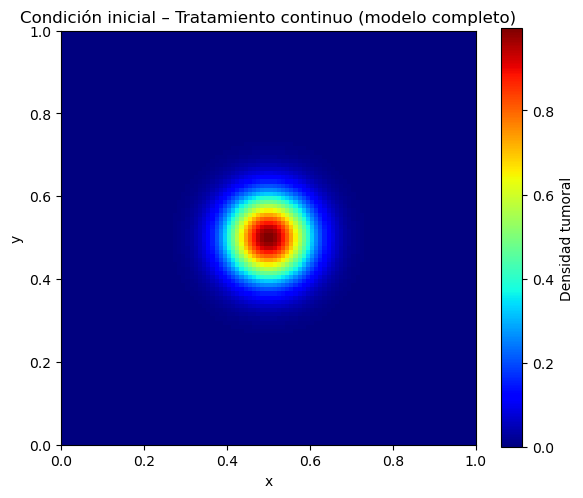

100%|██████████| 150000/150000 [01:19<00:00, 1878.90it/s]
C:\Users\fatim\AppData\Local\Temp\ipykernel_6384\3082784672.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


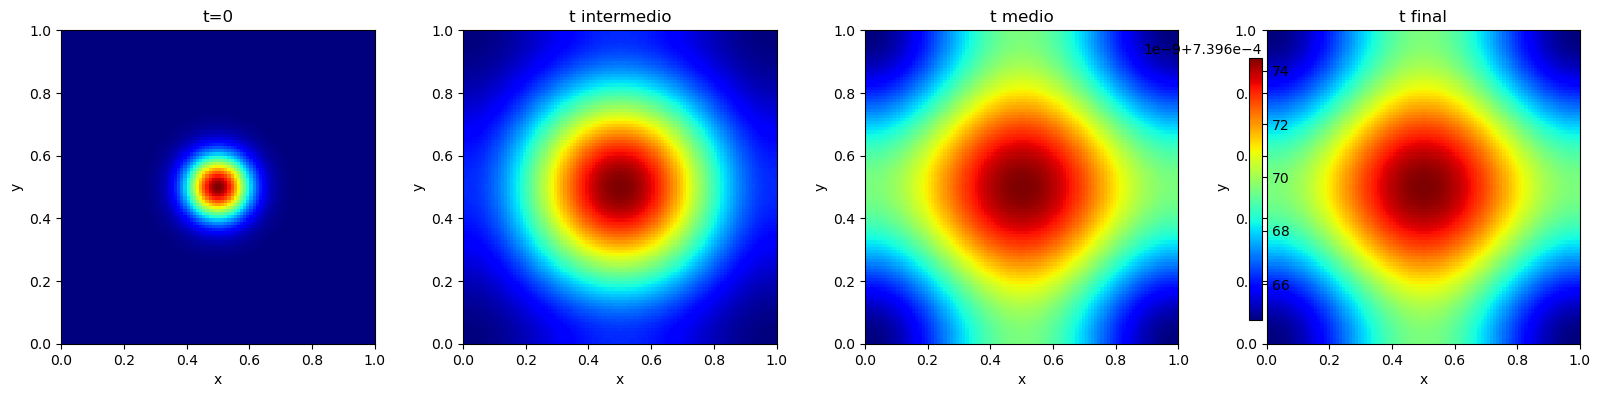

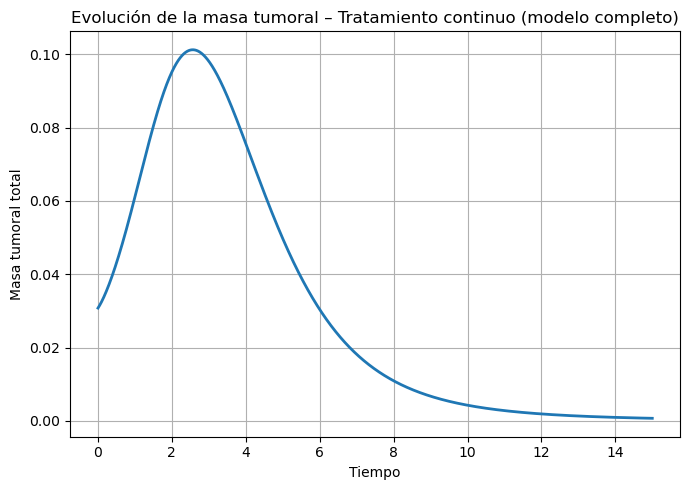


Simulación con tratamiento continuo (modelo completo) finalizada correctamente.
Archivos generados:
- condicion_inicial_tratamiento_continuo.png
- evolucion_tumor_tratamiento_continuo.png
- masa_tumoral_tratamiento_continuo.png
- evolucion_tratamiento_continuo.gif
Guardado en: C:\Users\fatim\Desktop\TFM_Tratamiento_Continuo_Completo


In [2]:
# =====================================================
# LIBRERÍAS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os
from tqdm import tqdm

# =====================================================
# CREAR CARPETA EN EL ESCRITORIO
# =====================================================

ruta_escritorio = os.path.join(os.path.expanduser("~"), "Desktop")
ruta_figuras = os.path.join(ruta_escritorio, "TFM_Tratamiento_Continuo_Completo")

os.makedirs(ruta_figuras, exist_ok=True)

print(f"Resultados guardados en: {ruta_figuras}")

# =====================================================
# PARÁMETROS DEL MODELO
# =====================================================

D = 0.01
mu = 0.02
a = 0.5
K = 1.0
gamma = 1.0
delta = 0.1
u0 = 0.5

# =====================================================
# DOMINIO ESPACIAL
# =====================================================

Lx, Ly = 1.0, 1.0
Nx, Ny = 100, 100

dx = Lx / Nx
dy = Ly / Ny

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

X, Y = np.meshgrid(x, y, indexing='ij')

# =====================================================
# DISCRETIZACIÓN TEMPORAL
# =====================================================

T = 15.0
dt = 1e-4
Nt = int(T / dt)

print(f"Pasos temporales: {Nt}")

# =====================================================
# # CONDICIÓN CFL (IMPORTANTE)
# =====================================================

cfl_c = dt <= dx**2 / (4 * D)
cfl_b = dt <= dx**2 / (4 * mu)

print(f"CFL (c) satisfecha: {cfl_c}")
print(f"CFL (beta) satisfecha: {cfl_b}")

# =====================================================
# CONDICIÓN INICIAL
# =====================================================

x0, y0 = 0.5, 0.5
sigma = 0.10
c0 = 1.0

c = c0 * np.exp(-((X - x0)**2 + (Y - y0)**2) / sigma**2)
beta = np.zeros_like(c)

# =====================================================
# FIGURA 1: CONDICIÓN INICIAL
# =====================================================

plt.figure(figsize=(6,5))
plt.imshow(c, extent=[0,1,0,1], origin='lower', cmap='jet')
plt.colorbar(label='Densidad tumoral')
plt.title('Condición inicial – Tratamiento continuo (modelo completo)')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.savefig(os.path.join(ruta_figuras, 'condicion_inicial_tratamiento_continuo.png'), dpi=300)
plt.show()

# =====================================================
# LAPLACIANO
# =====================================================

def laplaciano(Z):
    return (
        (np.roll(Z, -1, axis=0) - 2*Z + np.roll(Z, 1, axis=0)) / dx**2 +
        (np.roll(Z, -1, axis=1) - 2*Z + np.roll(Z, 1, axis=1)) / dy**2
    )

# =====================================================
# LISTAS PARA GUARDAR RESULTADOS
# =====================================================

masa = []
frames = []

# =====================================================
# SIMULACIÓN
# =====================================================

for n in tqdm(range(Nt)):

    c_old = c.copy()
    beta_old = beta.copy()

    lap_c = laplaciano(c_old)
    lap_beta = laplaciano(beta_old)

    reaction = a * c_old * np.log(K / (c_old + 1e-12))
    interaction = gamma * c_old * beta_old

    c = c_old + dt * (D * lap_c + reaction - interaction)

    beta = beta_old + dt * (
        mu * lap_beta
        - delta * beta_old
        + u0
    )

    c = np.maximum(c, 0)
    beta = np.maximum(beta, 0)

    for Z in [c, beta]:
        Z[0, :] = Z[1, :]
        Z[-1, :] = Z[-2, :]
        Z[:, 0] = Z[:, 1]
        Z[:, -1] = Z[:, -2]

    masa.append(np.sum(c) * dx * dy)

    if n % 200 == 0:
        frames.append(c.copy())

# =====================================================
# FIGURA 2: EVOLUCIÓN ESPACIAL
# =====================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

indices = [
    0,
    len(frames)//10,
    len(frames)//2,
    -1
]

titulos = [
    't=0',
    't intermedio',
    't medio',
    't final'
]

for ax, idx, titulo in zip(axes, indices, titulos):

    im = ax.imshow(frames[idx], extent=[0,1,0,1],
                   origin='lower', cmap='jet')

    ax.set_title(titulo)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)

plt.tight_layout()
plt.savefig(os.path.join(ruta_figuras, 'evolucion_tumor_tratamiento_continuo.png'), dpi=300)
plt.show()

# =====================================================
# FIGURA 3: MASA TUMORAL
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(np.linspace(0, T, len(masa)), masa, linewidth=2)

plt.xlabel('Tiempo')
plt.ylabel('Masa tumoral total')
plt.title('Evolución de la masa tumoral – Tratamiento continuo (modelo completo)')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(ruta_figuras, 'masa_tumoral_tratamiento_continuo.png'), dpi=300)
plt.show()

# =====================================================
# GIF
# =====================================================

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(frames[0], extent=[0,1,0,1],
               origin='lower', cmap='jet', animated=True)

ax.set_title('Evolución tumoral – Tratamiento continuo (modelo completo)')

def update(frame):
    im.set_array(frame)
    return [im]

ani = FuncAnimation(fig, update, frames=frames,
                    interval=100, blit=True)

ani.save(
    os.path.join(ruta_figuras, 'evolucion_tratamiento_continuo.gif'),
    writer=PillowWriter(fps=10)
)

plt.close()

# =====================================================
# MENSAJE FINAL
# =====================================================

print("\nSimulación con tratamiento continuo (modelo completo) finalizada correctamente.")
print("Archivos generados:")
print("- condicion_inicial_tratamiento_continuo.png")
print("- evolucion_tumor_tratamiento_continuo.png")
print("- masa_tumoral_tratamiento_continuo.png")
print("- evolucion_tratamiento_continuo.gif")

print(f"Guardado en: {ruta_figuras}")